# Differentiable Peng–Robinson flash and state properties

This notebook exercises the primary `torch-flash` workflow: evaluate a
homogeneous state without solving equilibrium, differentiate its properties,
and then perform an isothermal two-phase flash. SI units and `float64` are
used throughout.

**Model scope.** PR78 with van der Waals one-fluid mixing and `kij = 0` is a
deliberately transparent hydrocarbon baseline, not a universal fluid model.

Primary sources:

- Peng and Robinson's original cubic equation:
  <https://doi.org/10.1021/i160057a011>
- the 1978 acentric-factor extension: Robinson and Peng, GPA Research Report
  RR-28 (1978), <https://books.google.com/books?id=bE-_HAAACAAJ>
- Michelsen's stability and phase-split algorithms:
  <https://doi.org/10.1016/0378-3812(82)85001-2> and
  <https://doi.org/10.1016/0378-3812(82)85002-4>

In [1]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from torch_flash import (
    ChemicalState,
    component_set,
    peng_robinson_1978,
    phase_envelope,
    phase_properties,
    state_derivatives,
    two_phase_flash,
    volume_to_covolume_ratio,
)

torch.set_default_dtype(torch.float64)
print({"torch": torch.__version__, "torch-flash": version("torch-flash")})

{'torch': '2.12.1', 'torch-flash': '0.1.0'}


## A specified homogeneous state

No flash calculation is hidden in `phase_properties`: the requested root is
evaluated at the composition supplied by the caller. This separation is
useful when thermodynamic outputs become features or losses in an ML model.

In [2]:
components = component_set(("methane", "n_butane"))
model = peng_robinson_1978(components)
state = ChemicalState(
    temperature=torch.tensor(270.0),
    pressure=torch.tensor(3.0e6),
    composition=torch.tensor([0.5, 0.5]),
)

homogeneous = phase_properties(model, state, "stable")
pd.Series(
    {
        "Z": homogeneous.compressibility_factor.item(),
        "molar volume [m3/mol]": homogeneous.molar_volume.item(),
        "likely phase": homogeneous.phase_identification.kind,
        "V/b": homogeneous.phase_identification.criterion_value.item(),
        "phase ID ambiguous": homogeneous.phase_identification.ambiguous,
        "G [J/mol, chosen standard state]": homogeneous.molar_gibbs_energy.item(),
        "Hres [J/mol]": homogeneous.residual_enthalpy.item(),
        "Sres [J/(mol K)]": homogeneous.residual_entropy.item(),
    }
)

Z                                       0.104568
molar volume [m3/mol]                   0.000078
likely phase                              liquid
V/b                                     1.576921
phase ID ambiguous                         False
G [J/mol, chosen standard state]     3822.766164
Hres [J/mol]                       -13215.924518
Sres [J/(mol K)]                       -40.59028
dtype: object

Chemical potentials use a zero ideal-gas standard chemical potential at
1 bar unless an explicit `StandardState` model is supplied. Their absolute
zeros therefore must not be interpreted as formation properties.

In [3]:
derivatives = state_derivatives(model, state)
pd.DataFrame(
    {
        "mu [J/mol]": homogeneous.chemical_potentials.detach().numpy(),
        "dmu/dT [J/(mol K)]": derivatives.dchemical_potential_dtemperature.detach().numpy(),
        "dmu/dP [m3/mol]": derivatives.dchemical_potential_dpressure.detach().numpy(),
    },
    index=components.names,
)

,mu [J/mol],dmu/dT [J/(mol K)],dmu/dP [m3/mol]
methane,8867.575514,42.827391,0.000083
n_butane,-1222.043186,83.385132,0.000074


In [4]:
print("dmu/d independent composition:")
display(
    pd.DataFrame(
        derivatives.dchemical_potential_dindependent_composition.detach().numpy(),
        index=components.names,
        columns=[f"x_{components.names[0]} (x_last dependent)"],
    )
)
print("dG/dP [m3/mol]:", derivatives.dgibbs_dpressure.item())

dmu/d independent composition:


,x_methane (x_last dependent)
methane,1962.821484
n_butane,-1962.821484


dG/dP [m3/mol]: 7.82480798142495e-05


## Two-phase flash

At equilibrium, each component's liquid and vapor fugacity must agree. The
reported residual below is evaluated independently from the solver flag.

In [5]:
flash = two_phase_flash(model, state, check_stability=False)
liquid, vapor = flash.phases
fugacity_l = (
    liquid.composition * torch.exp(liquid.log_fugacity_coefficients) * state.pressure
)
fugacity_v = (
    vapor.composition * torch.exp(vapor.log_fugacity_coefficients) * state.pressure
)

display(
    pd.DataFrame(
        {
            "overall z": state.composition.numpy(),
            "liquid x": liquid.composition.detach().numpy(),
            "vapor y": vapor.composition.detach().numpy(),
            "fL [Pa]": fugacity_l.detach().numpy(),
            "fV [Pa]": fugacity_v.detach().numpy(),
        },
        index=components.names,
    )
)
print(
    {
        "phase fractions [L,V]": flash.phase_fractions.detach().numpy(),
        "identified phase kinds": flash.phase_kinds,
        "phase regime": flash.phase_regime,
        "converged": flash.converged,
        "max relative fugacity mismatch": (
            ((fugacity_l - fugacity_v).abs() / torch.maximum(fugacity_l, fugacity_v))
            .max()
            .item()
        ),
    }
)

,overall z,liquid x,vapor y,fL [Pa],fV [Pa]
methane,0.5,0.199437,0.950124,2.608854e+06,2.608854e+06
n_butane,0.5,0.800563,0.049876,8.069616e+04,8.069616e+04


{'phase fractions [L,V]': array([0.59961631, 0.40038369]), 'identified phase kinds': ('liquid', 'vapor'), 'phase regime': 'vapor-liquid', 'converged': True, 'max relative fugacity mismatch': 4.132372646318721e-11}


## Phase identification and a colored phase map

The solver root requested through `PhaseProperties.kind` is not itself a
physical phase identification. `torch-flash` records that distinction:

- for a cubic-family homogeneous phase, the default classifier uses
  \(V/b < 1.75\) for liquid and \(V/b > 1.75\) for vapor;
- a value within 5% of the divider is marked `ambiguous`, although the
  deterministic side of the divider is still reported;
- for a flashed model without a cubic covolume, molar-volume ordering is a
  documented weaker fallback.

These conventions follow Pedersen, Christensen, and Shaikh (2024),
section 6.6, [doi:10.1201/9780429457418](https://doi.org/10.1201/9780429457418).
ThermoPack similarly exposes a single-root phase guess based on
pseudo-critical information or a volume/covolume ratio; NeqSim exposes the
resulting gas/oil phase type. Those APIs informed the result design, but are
not experimental validation of this discrete label.

In [6]:
phase_identification_table = pd.DataFrame(
    [
        {
            "requested EoS root": phase.kind,
            "identified kind": identification.kind,
            "method": identification.method,
            "V/b": identification.criterion_value.item(),
            "threshold": identification.threshold.item(),
            "ambiguous": identification.ambiguous,
        }
        for phase, identification in zip(
            flash.phases,
            flash.phase_identifications,
            strict=True,
        )
    ],
    index=["phase 0", "phase 1"],
)
phase_identification_table

,requested EoS root,identified kind,method,V/b,threshold,ambiguous
phase 0,liquid,liquid,pedersen-volume-to-covolume,1.320723,1.75,False
phase 1,vapor,vapor,pedersen-volume-to-covolume,22.792278,1.75,False


The map below is an isopleth at fixed overall composition. Its two-phase
band is obtained from independently solved bubble/dew pressures; outside
that band, the stable homogeneous PR78 root is colored by the same batched
\(V/b\) diagnostic used in the flash result. Thus an unstable homogeneous
root is never used to color the two-phase region. This is a
continuation-valid window, not a critical-point arclength trace.

In [7]:
map_temperatures = torch.linspace(210.0, 360.0, 61)
map_pressures = torch.logspace(
    torch.log10(torch.tensor(5.0e3)),
    torch.log10(torch.tensor(1.5e7)),
    120,
)
map_envelope = phase_envelope(model, map_temperatures, state.composition)
bubble_pressures = torch.stack(
    tuple(point.pressure for point in map_envelope["bubble"])
)
dew_pressures = torch.stack(tuple(point.pressure for point in map_envelope["dew"]))
assert all(point.converged for branch in map_envelope.values() for point in branch)

temperature_grid = map_temperatures.unsqueeze(0).expand(map_pressures.numel(), -1)
pressure_grid = map_pressures.unsqueeze(1).expand(-1, map_temperatures.numel())
composition_grid = state.composition.reshape(1, 1, -1).expand(
    *temperature_grid.shape,
    -1,
)
grid_state = ChemicalState(temperature_grid, pressure_grid, composition_grid)
volume_ratio_grid = volume_to_covolume_ratio(model, grid_state)
inside_envelope = (pressure_grid >= dew_pressures.unsqueeze(0)) & (
    pressure_grid <= bubble_pressures.unsqueeze(0)
)

# Codes: 0 liquid, 1 vapor-liquid, 2 vapor.
phase_codes = torch.where(
    inside_envelope,
    torch.ones_like(volume_ratio_grid, dtype=torch.int64),
    torch.where(
        volume_ratio_grid < 1.75,
        torch.zeros_like(volume_ratio_grid, dtype=torch.int64),
        torch.full_like(volume_ratio_grid, 2, dtype=torch.int64),
    ),
)
ambiguous_single_phase = (~inside_envelope) & (
    torch.abs(torch.log(volume_ratio_grid / 1.75)) <= torch.log(torch.tensor(1.05))
)

In [8]:
check_conditions = ((270.0, 0.05e6), (270.0, 3.0e6), (270.0, 10.0e6))
flash_checks = []
for temperature, pressure in check_conditions:
    check_state = ChemicalState(
        torch.tensor(temperature),
        torch.tensor(pressure),
        state.composition,
    )
    check = two_phase_flash(model, check_state)
    flash_checks.append(
        {
            "T [K]": temperature,
            "P [MPa]": pressure / 1.0e6,
            "flash regime": check.phase_regime,
            "converged": check.converged,
            "phase kinds": ", ".join(check.phase_kinds),
        }
    )
flash_check_frame = pd.DataFrame(flash_checks)
flash_check_frame

,T [K],P [MPa],flash regime,converged,phase kinds
0,270.0,0.05,vapor,True,vapor
1,270.0,3.00,vapor-liquid,True,"liquid, vapor"
2,270.0,10.00,liquid,True,liquid


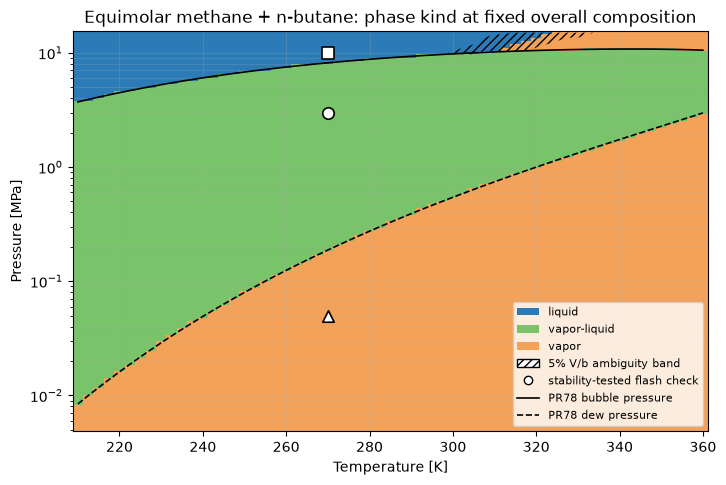

In [9]:
colors = ["#2c7bb6", "#79c36a", "#f4a259"]
fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.pcolormesh(
    map_temperatures.detach().numpy(),
    (map_pressures / 1.0e6).detach().numpy(),
    phase_codes.detach().numpy(),
    cmap=ListedColormap(colors),
    shading="nearest",
    vmin=-0.5,
    vmax=2.5,
)
ax.plot(
    map_temperatures,
    bubble_pressures / 1.0e6,
    color="black",
    linewidth=1.2,
    label="PR78 bubble pressure",
)
ax.plot(
    map_temperatures,
    dew_pressures / 1.0e6,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="PR78 dew pressure",
)
ax.contourf(
    map_temperatures.detach().numpy(),
    (map_pressures / 1.0e6).detach().numpy(),
    ambiguous_single_phase.detach().numpy(),
    levels=[0.5, 1.5],
    colors="none",
    hatches=["////"],
)

regime_markers = {"liquid": "s", "vapor-liquid": "o", "vapor": "^"}
for row in flash_check_frame.itertuples(index=False):
    ax.scatter(
        row[0],
        row[1],
        marker=regime_markers[row[2]],
        s=68,
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        zorder=4,
    )

phase_legend = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for color, label in zip(colors, ("liquid", "vapor-liquid", "vapor"), strict=True)
]
diagnostic_legend = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="////",
        label="5% V/b ambiguity band",
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        label="stability-tested flash check",
    ),
]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(
    handles=phase_legend + diagnostic_legend + line_handles,
    labels=[item.get_label() for item in phase_legend + diagnostic_legend]
    + line_labels,
    loc="lower right",
    fontsize=8,
)
ax.set(
    xlabel="Temperature [K]",
    ylabel="Pressure [MPa]",
    title="Equimolar methane + n-butane: phase kind at fixed overall composition",
)
ax.set_yscale("log")
ax.grid(alpha=0.2, which="both")
plt.show()

White symbols are actual stability-tested flash calls in the three colored
regimes. Hatching marks the 5% ambiguity band around \(V/b=1.75\). The phase
name is a practical engineering convention: changing it does not change
fugacity, free energy, density, or the equilibrium solution.

## Batched execution and model-parameter gradients

In [10]:
temperatures = torch.tensor([250.0, 270.0, 300.0, 350.0])
pressures = torch.tensor([1.0e6, 3.0e6, 5.0e6, 1.0e6])
compositions = torch.tensor([[0.2, 0.8], [0.5, 0.5], [0.7, 0.3], [0.4, 0.6]])
roots = model.z_factors(temperatures, pressures, compositions)
pd.DataFrame(
    roots.detach().numpy(), columns=["small root", "middle root", "large root"]
)

,small root,middle root,large root
0,0.038793,0.038793,0.038793
1,0.104568,0.104568,0.104568
2,0.596857,0.596857,0.596857
3,0.907130,0.907130,0.907130


In [11]:
trainable_model = peng_robinson_1978(
    components,
    kij=torch.zeros((2, 2)),
    trainable=True,
)
target_z = torch.tensor(0.60)
predicted_z = trainable_model.select_z(
    torch.tensor(300.0),
    torch.tensor(5.0e6),
    torch.tensor([0.7, 0.3]),
)
loss = (predicted_z - target_z).square()
loss.backward()
print(
    {
        "predicted Z": predicted_z.item(),
        "loss": loss.item(),
        "gradient of raw kij": trainable_model.mixing.raw_kij.grad.detach().numpy(),
    }
)

{'predicted Z': 0.596856586277012, 'loss': 9.881049833869194e-06, 'gradient of raw kij': array([[ 0.        , -0.00159823],
       [-0.00159823,  0.        ]])}


The symmetric off-diagonal gradient is directly usable by a PyTorch
optimizer. Near critical points, root coalescence makes any cubic-EoS
derivative ill-conditioned; that is a physical/numerical singularity rather
than an autodiff defect and should be diagnosed in downstream fits.